# GenerativeTerrain — Terrain Generation Pipeline

This notebook is a **thin driver**: every heavy operation lives in the
`gt_terrain` package (`ml/gt_terrain/`), which is unit-tested and importable. The
notebook's job is to narrate the pipeline and show results.

## Why the old approach generated poorly

The previous models conditioned each voxel prediction on the **block IDs of its
six neighbours**, plus `Is_Surface` and `Light_Level`. All of those describe the
terrain *being generated* — so the model learned the trivial task *"fill this
hole given the blocks around it"* and never learned to generate anything. At
generation time those neighbours don't exist, so the model was fed zeros and
produced garbage.

**The fix is conceptual, not architectural.** A terrain generator may only
condition on what exists *before* terrain does:

* **position** (especially height `y`),
* the **chunk biome**,
* and — for variety — a **latent noise vector `z`**.

## What we build here

1. A correct, leakage-free data pipeline (`gt_terrain.data`).
2. A **deterministic baseline** that conditions on `(position, biome)` — it sets
   an accuracy floor and proves the pipeline (`BaselineVoxelNet`).
3. A **conditional VAE** that adds latent `z`, so sampling different `z` gives
   different terrain (`ConditionalTerrainVAE`).
4. Evaluation focused on **terrain plausibility** (vertical block profiles),
   plus ONNX export for the Java plugin.

In [1]:
# --- Make the gt_terrain package importable regardless of where Jupyter started.
import sys
from pathlib import Path

ML_DIR = Path.cwd()
while ML_DIR.name != "ml" and ML_DIR != ML_DIR.parent:
    ML_DIR = ML_DIR.parent
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

from gt_terrain.config import Config
from gt_terrain.blocks import BlockGrouping
from gt_terrain import data, train, evaluate, generate, export

# Standard config picks GPU automatically. For a quick CPU dry-run use:
#   cfg = Config.tiny()
cfg = Config()
print("device:", cfg.device)
print("data_dir:", cfg.data_dir)
print("artifact_dir:", cfg.artifact_dir)

device: cuda
data_dir: C:\Users\cathe\Desktop\Plugins\Server\block_dataset
artifact_dir: C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\ml\artifacts


## Step 1 — Data

Each CSV is one full chunk (16 × 384 × 16 voxels). We read **only** `x, y, z`,
`ChunkBiome`, and `Block_ID`; the leakage columns are never touched (a unit test
enforces this). Block names are collapsed into 27 semantic groups, and the whole
dataset is gridded into one in-memory int8 array (~100 KB per chunk) — no
per-chunk `.pt` files. The biome vocabulary always includes a reserved
`UNKNOWN` entry (see Step 3).

In [2]:
grouping = BlockGrouping()
biome_encoder = data.BiomeEncoder.from_csvs(data.list_csv_files(cfg))
grids, biome_ids = data.build_dataset(cfg, grouping, biome_encoder)

print(f"chunks: {grids.shape[0]}   grid shape per chunk: {grids.shape[1:]}")
print(f"block groups (classes): {grouping.num_classes}")
print(f"biomes: {biome_encoder.num_biomes} -> {biome_encoder.names}")

class_weights = data.compute_class_weights(grids, grouping.num_classes)
print("class-weight range:", round(float(class_weights.min()), 3),
      "to", round(float(class_weights.max()), 3))

chunks: 1751   grid shape per chunk: (16, 384, 16)
block groups (classes): 27
biomes: 21 -> ['BADLANDS', 'BAMBOO_JUNGLE', 'BEACH', 'BIRCH_FOREST', 'COLD_OCEAN', 'DARK_FOREST', 'DESERT', 'ERODED_BADLANDS', 'FLOWER_FOREST', 'FOREST', 'LUKEWARM_OCEAN', 'MANGROVE_SWAMP', 'OCEAN', 'OLD_GROWTH_BIRCH_FOREST', 'PLAINS', 'RIVER', 'SAVANNA', 'SPARSE_JUNGLE', 'SUNFLOWER_PLAINS', 'SWAMP', 'TAIGA']
class-weight range: 0.259 to 1.067


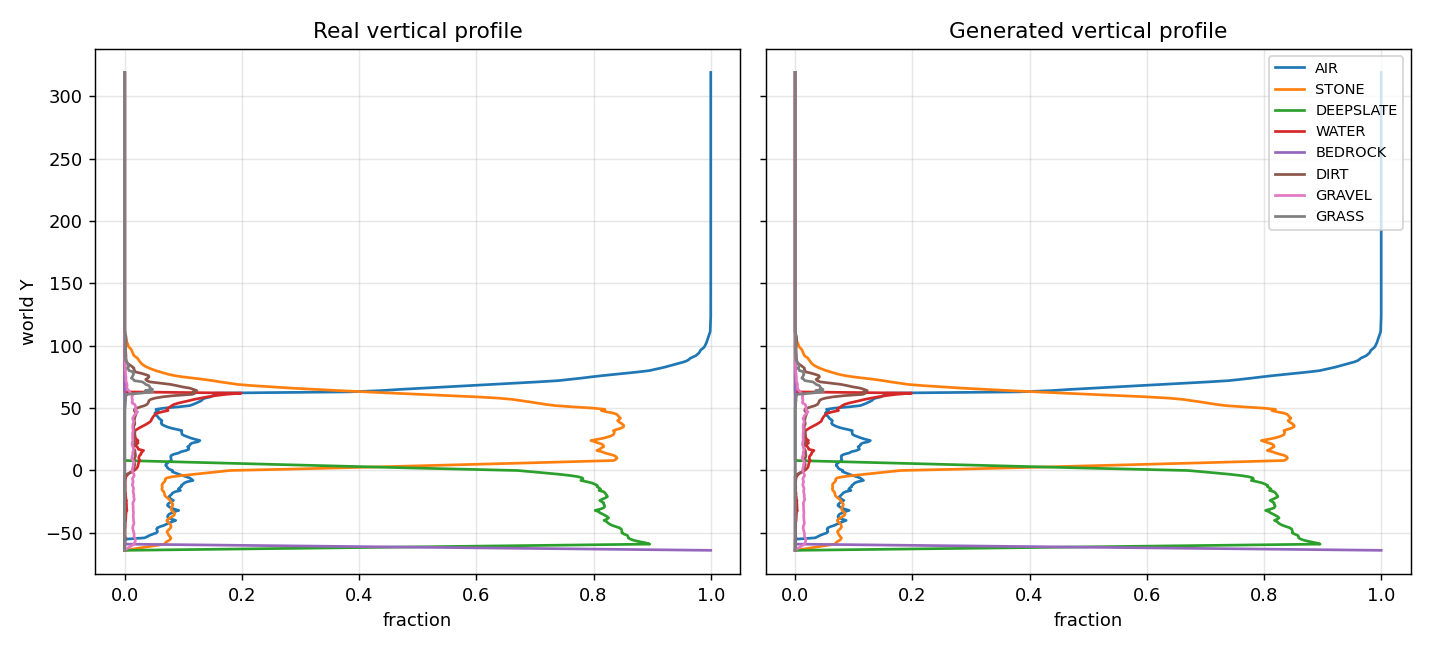

In [3]:
# Sanity check: the average vertical profile of the REAL data should look like
# terrain (bedrock floor, stone body, a thin surface band, air on top).
evaluate.plot_vertical_profiles(
    grids, grids, grouping, cfg, cfg.artifact_dir / "real_profile.png"
)
from IPython.display import Image
Image(str(cfg.artifact_dir / "real_profile.png"))

## Step 2 — Baseline (deterministic)

`BaselineVoxelNet` maps `(position, biome) → block-group logits`. Because it has
no source of randomness, it can only learn the *average* terrain for a biome:
expect smooth, layered output (correct block-by-height, but no hills, caves, or
trees). That is exactly the point — it gives us a number to beat and confirms the
plumbing end to end.

In [4]:
baseline, baseline_hist = train.train_baseline(
    cfg, grids, biome_ids, class_weights, grouping.num_classes, biome_encoder.num_biomes
)
evaluate.plot_training_curves(baseline_hist, cfg.artifact_dir / "baseline_curves.png", "Baseline")

_, _, test_loader = train.make_loaders(grids, biome_ids, cfg)
acc = evaluate.baseline_accuracy(baseline, test_loader, cfg)
print("baseline test accuracy:", round(acc["overall"], 4))
print("per-group accuracy (non-empty groups):")
for cid, a in acc["per_group"].items():
    if a == a:  # skip NaN (group absent in test set)
        print(f"  {grouping.idx_to_group[cid]:14s} {a:.3f}")

baseline e1 train:   0%|          | 0/154 [00:00<?, ?it/s]

[baseline] epoch 1 train 1.9151 val 1.4115


baseline e2 train:   0%|          | 0/154 [00:00<?, ?it/s]

[baseline] epoch 2 train 1.1456 val 0.9419


baseline e3 train:   0%|          | 0/154 [00:00<?, ?it/s]

...

[baseline] epoch 182 train 0.4553 val 0.5192


baseline e183 train:   0%|          | 0/154 [00:00<?, ?it/s]

[baseline] epoch 183 train 0.4542 val 0.5164
[baseline] early stop at epoch 183


C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\ml\gt_terrain\train.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

baseline test accuracy: 0.915
per-group accuracy (non-empty groups):
  AIR            0.953
  STONE          0.860
  DEEPSLATE      0.956
  DIRT           0.152
  GRASS          0.002
  SAND           0.231
  GRAVEL         0.000
  CLAY           0.000
  WATER          0.275
  LAVA           0.000
  BEDROCK        0.932
  COAL_ORE       0.000
  IRON_ORE       0.000
  COPPER_ORE     0.000
  GOLD_ORE       0.000
  REDSTONE_ORE   0.000
  LAPIS_ORE      0.000
  DIAMOND_ORE    0.000
  OAK_WOOD       0.000
  BIRCH_WOOD     0.000
  JUNGLE_WOOD    0.000
  ACACIA_WOOD    0.000
  DARK_OAK_WOOD  0.443
  VEGETATION     0.000
  MISC           0.000


## Step 3 — Conditional VAE (the generator)

The VAE adds a latent `z`: an encoder compresses each real chunk into a
**spatial** latent grid, and the decoder reconstructs the chunk from
`z + biome + position` — first committing to a per-column surface heightmap,
then filling the volume with a 3D U-Net. Sampling `z ~ N(0, I)` at generation
time is what produces *varied* terrain.

Training details handled inside `train_vae`:

* **KL annealing + free bits** keep the model from ignoring `z`;
* **EMA weights** are validated and exported (steadier sample quality);
* **AMP** (mixed precision) roughly halves step time on the GPU;
* **warmup + cosine LR** schedule;
* **biome dropout** trains the reserved `UNKNOWN` biome row on generic terrain,
  so fine-tuning data from custom worlds with unrecognised biomes still works;
* **style-noise regularisation** keeps the style space smooth around the base
  style — this is what makes the model *fine-tunable* later (see
  `FineTune.ipynb`).

In [ ]:
vae, vae_hist = train.train_vae(
    cfg, grids, biome_ids, class_weights, grouping.num_classes, biome_encoder.num_biomes,
    unknown_biome_id=biome_encoder.unknown_id,   # enables biome dropout
)
evaluate.plot_training_curves(vae_hist, cfg.artifact_dir / "vae_curves.png", "VAE")
Image(str(cfg.artifact_dir / "vae_curves.png"))

## Step 4 — Generate & evaluate

We sample several chunks for one biome and check two things:

* **diversity** — how much samples differ (0.0 would mean posterior collapse:
  every sample identical);
* **vertical profile** — generated vs real. The closer the generated profile is
  to the real one, the more plausible the terrain.

biome: BADLANDS
sample diversity: 0.075


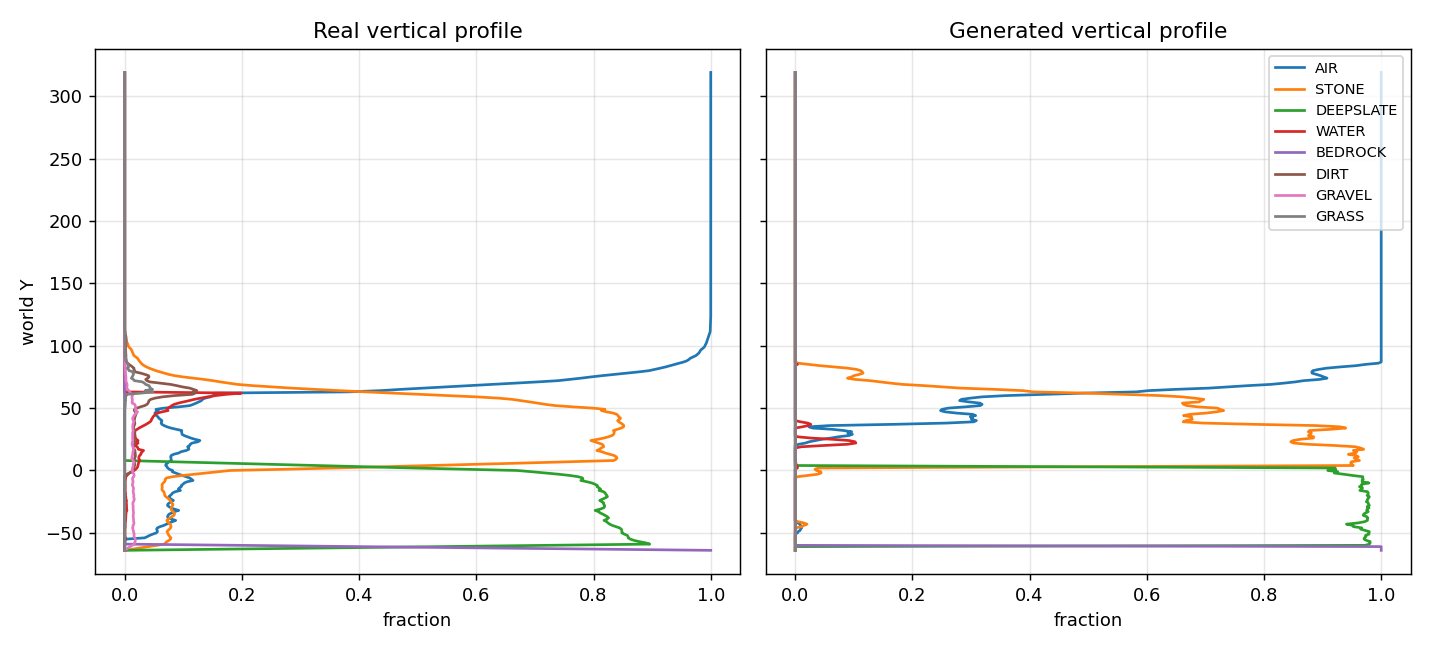

In [6]:
biome_name = biome_encoder.names[0]
biome_id = biome_encoder.transform(biome_name)
samples = generate.sample_grids(vae, biome_id, n=6, config=cfg)

print(f"biome: {biome_name}")
print("sample diversity:", round(evaluate.sample_diversity(samples), 4))

evaluate.plot_vertical_profiles(
    grids, samples, grouping, cfg, cfg.artifact_dir / "profiles.png"
)
Image(str(cfg.artifact_dir / "profiles.png"))

In [7]:
# Write one sample to a block-name CSV you can inspect (same schema the plugin uses).
df = generate.grid_to_csv(samples[0], grouping, cfg, cfg.artifact_dir / "generated_chunk_sample.csv")
df["Block_ID"].value_counts().head(12)

Block_ID
AIR                       67797
DEEPSLATE                 14875
STONE                     13667
BEDROCK                    1024
COAL_ORE                    167
IRON_ORE                    142
DEEPSLATE_IRON_ORE          126
DEEPSLATE_REDSTONE_ORE      117
COPPER_ORE                  101
DEEPSLATE_GOLD_ORE           61
DEEPSLATE_LAPIS_ORE          42
LAPIS_ORE                    42
Name: count, dtype: int64

## Step 5 — Freeze the versioned base checkpoint

Once you are happy with the samples above, freeze this model as **the base**.
`save_base_checkpoint` writes a self-contained directory
(`artifacts/base_v1/`): the weights plus a manifest recording the exact
architecture and mappings. This is what `FineTune.ipynb` (and anyone else's
fine-tune) builds on — the manifest guarantees the fine-tune reconstructs the
model correctly, so version mismatches are impossible.

In [ ]:
base_dir = train.save_base_checkpoint(
    vae, cfg, grouping, biome_encoder, dataset_chunks=len(grids)
)
sorted(p.name for p in base_dir.iterdir())

## Step 6 — Export for the Java plugin

Export the **decoder only** to ONNX (`(z, biome_id, style_id) → logits`) and
write the three JSON mappings the plugin reads. Copy all four files into your
server's `plugins/GenerativeTerrain/` folder. In game, `/generateterrain`
uses the base style by default; after fine-tuning, `/generateterrain style
<name>` selects a custom style.

In [ ]:
onnx_path = export.export_decoder_onnx(vae, cfg)
group_map, biome_map, style_map = export.write_mappings(grouping, biome_encoder, cfg)
out_shape = export.verify_onnx(onnx_path, cfg, biome_encoder.num_biomes)

print("ONNX decoder :", onnx_path)
print("output shape :", out_shape, "(expected (1, 27, 16, 384, 16))")
print("group mapping:", group_map)
print("biome mapping:", biome_map)
print("style mapping:", style_map)
print("\nCopy these into: <server>/plugins/GenerativeTerrain/")

## Where to go next

* **Fine-tune on custom terrain** — the headline feature. Open
  `FineTune.ipynb`: it loads the frozen base from `artifacts/base_v1/`, trains
  a new *style* on any folder of chunk CSVs, and exports one model that serves
  both the base style and the custom one (`/generateterrain style <name>`).
* **More data** is still the highest-leverage quality change — especially for
  rare biomes (`/grabbiome`, `/grabblock`).
* **Scale the model** as data grows: `base_channels`, `latent_channels`, the
  `latent_grid` resolution, and `epochs`.
* **Spatial continuity across chunks** is a known limitation (each chunk is
  generated independently). A future step is to condition on neighbouring
  *generated* chunk edges — legitimately, since by then they exist.